# Motor Insurance Portfolio Simulation & Risk Analytics

## Project Overview
This project simulates a large-scale motor insurance portfolio of 1,000,000 policies and evaluates written premium, claim emergence, profitability, earned premium recognition, and remaining risk exposure.

The objective is to assess whether the simulated portfolio is sustainably priced under a simplified rule-based insurance scenario.

## Why this project matters
This project demonstrates:
- large-scale portfolio simulation using Python
- rule-based policy and claims modelling
- insurance-focused business analytics
- pricing adequacy and underwriting interpretation

## Core business question
Under the current premium and claims assumptions, is the simulated portfolio structurally profitable?


## 1. Setup and Core Assumptions
This section imports the required libraries and defines the fixed assumptions used to construct the portfolio and claims simulation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# portfolio assumptions
TOTAL_POLICIES = 1_000_000
VEHICLE_VALUE = 100_000
CLAIM_AMOUNT = int(VEHICLE_VALUE * 0.10)

# sales period
SALES_START = "2024-01-01"
SALES_END = "2024-12-31"

# 2026 claim window
CLAIM_2026_START = "2026-01-01"
CLAIM_2026_END = "2026-02-28"

# tenure distribution
TENURE_MIX = {
    1: 0.20,
    2: 0.30,
    3: 0.40,
    4: 0.10
}

## 2. Policy Portfolio Simulation
This section simulates 1,000,000 policy sales across all days of 2024 and assigns policy tenures according to the required mix. The resulting dataset forms the base portfolio used for premium, lifecycle, and claims analysis.

In [3]:
def allocate_by_mix(total_count, mix_dict):
    raw = np.array([mix_dict[k] * total_count for k in mix_dict.keys()])
    base = np.floor(raw).astype(int)
    remainder = total_count - base.sum()

    order = np.argsort(-(raw - base))
    base[order[:remainder]] += 1

    return dict(zip(mix_dict.keys(), base))


sale_dates = pd.date_range(SALES_START, SALES_END, freq="D")
num_sale_days = len(sale_dates)

base_per_day = TOTAL_POLICIES // num_sale_days
remainder = TOTAL_POLICIES % num_sale_days

daily_policy_counts = np.full(num_sale_days, base_per_day, dtype=np.int32)
daily_policy_counts[:remainder] += 1

print(f"Total sale days in 2024: {num_sale_days}")
print(f"Base policies per day: {base_per_day}")
print(f"Extra 1-policy days needed: {remainder}")
print(f"Check total policies: {daily_policy_counts.sum():,}")

Total sale days in 2024: 366
Base policies per day: 2732
Extra 1-policy days needed: 88
Check total policies: 1,000,000


In [4]:
sale_dates_np = sale_dates.values.astype("datetime64[D]")
policy_purchase_dates = np.repeat(sale_dates_np, daily_policy_counts)

unique_daily_counts = np.unique(daily_policy_counts)
daily_mix_lookup = {n: allocate_by_mix(n, TENURE_MIX) for n in unique_daily_counts}

tenure_chunks = []
for n in daily_policy_counts:
    counts = daily_mix_lookup[n]
    chunk = np.concatenate([
        np.repeat(1, counts[1]),
        np.repeat(2, counts[2]),
        np.repeat(3, counts[3]),
        np.repeat(4, counts[4]),
    ])
    tenure_chunks.append(chunk)

policy_tenure = np.concatenate(tenure_chunks).astype(np.int8)

customer_id = np.arange(1, TOTAL_POLICIES + 1, dtype=np.int32)
vehicle_id = np.arange(1, TOTAL_POLICIES + 1, dtype=np.int32)

print(f"Purchase date rows: {len(policy_purchase_dates):,}")
print(f"Tenure rows: {len(policy_tenure):,}")
print("Tenure distribution counts:")
print(pd.Series(policy_tenure).value_counts().sort_index())

Purchase date rows: 1,000,000
Tenure rows: 1,000,000
Tenure distribution counts:
1    199924
2    300120
3    400038
4     99918
Name: count, dtype: int64


In [5]:
policy_start_dates = policy_purchase_dates + np.timedelta64(365, "D")
policy_tenure_days = policy_tenure.astype(np.int16) * 365
policy_end_dates = policy_start_dates + (policy_tenure_days - 1).astype("timedelta64[D]")

premium = policy_tenure.astype(np.int16) * 100

policy_sales = pd.DataFrame({
    "Customer_ID": customer_id,
    "Vehicle_ID": vehicle_id,
    "Vehicle_Value": VEHICLE_VALUE,
    "Premium": premium,
    "Policy_Purchase_Date": pd.to_datetime(policy_purchase_dates),
    "Policy_Start_Date": pd.to_datetime(policy_start_dates),
    "Policy_End_Date": pd.to_datetime(policy_end_dates),
    "Policy_Tenure": policy_tenure
})

print("Policy Sales Data created")
print(f"Rows: {len(policy_sales):,}")
display(policy_sales.head())
print(policy_sales.describe(include="all"))

Policy Sales Data created
Rows: 1,000,000


,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,1,1,100000,100,2024-01-01,2024-12-31,2025-12-30,1
1,2,2,100000,100,2024-01-01,2024-12-31,2025-12-30,1
2,3,3,100000,100,2024-01-01,2024-12-31,2025-12-30,1
3,4,4,100000,100,2024-01-01,2024-12-31,2025-12-30,1
4,5,5,100000,100,2024-01-01,2024-12-31,2025-12-30,1


       Customer_ID   Vehicle_ID  Vehicle_Value      Premium  \
count 1,000,000.00 1,000,000.00   1,000,000.00 1,000,000.00   
mean    500,000.50   500,000.50     100,000.00       240.00   
min           1.00         1.00     100,000.00       100.00   
25%     250,000.75   250,000.75     100,000.00       200.00   
50%     500,000.50   500,000.50     100,000.00       200.00   
75%     750,000.25   750,000.25     100,000.00       300.00   
max   1,000,000.00 1,000,000.00     100,000.00       400.00   
std     288,675.28   288,675.28           0.00        91.63   

      Policy_Purchase_Date    Policy_Start_Date      Policy_End_Date  \
count              1000000              1000000              1000000   
mean   2024-07-01 11:42:23  2025-07-01 11:42:23  2027-11-23 11:16:06   
min    2024-01-01 00:00:00  2024-12-31 00:00:00  2025-12-30 00:00:00   
25%    2024-04-01 00:00:00  2025-04-01 00:00:00  2027-03-01 00:00:00   
50%    2024-07-01 00:00:00  2025-07-01 00:00:00  2027-12-30 00:00:00   


In [6]:
# integrity checks
assert len(policy_sales) == TOTAL_POLICIES, "Policy row count mismatch"
assert policy_sales["Customer_ID"].nunique() == TOTAL_POLICIES, "Customer_ID should be unique"
assert policy_sales["Vehicle_ID"].nunique() == TOTAL_POLICIES, "Vehicle_ID should be unique"
assert (policy_sales["Policy_End_Date"] >= policy_sales["Policy_Start_Date"]).all(), "Invalid policy date range found"
assert policy_sales["Premium"].sum() > 0, "Premium sum should be positive"

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total policies",
        "Unique customers",
        "Unique vehicles",
        "Min purchase date",
        "Max purchase date",
        "Total written premium"
    ],
    "Value": [
        len(policy_sales),
        policy_sales["Customer_ID"].nunique(),
        policy_sales["Vehicle_ID"].nunique(),
        policy_sales["Policy_Purchase_Date"].min().date(),
        policy_sales["Policy_Purchase_Date"].max().date(),
        f"₹{policy_sales['Premium'].sum():,.2f}"
    ]
})

display(portfolio_summary)

,Metric,Value
0,Total policies,1000000
1,Unique customers,1000000
2,Unique vehicles,1000000
3,Min purchase date,2024-01-01
4,Max purchase date,2024-12-31
5,Total written premium,"₹239,995,000.00"


## 3. Portfolio Validation
Before generating claims, I validate the simulated portfolio to confirm that:
- policy sales are distributed nearly evenly across 2024
- the tenure distribution remains close to the target mix

This ensures that downstream claim and profitability differences arise from simulation rules rather than distortions in portfolio construction.

In [7]:
daily_sales_check = policy_sales.groupby("Policy_Purchase_Date").size().reset_index(name="Policies_Sold")

tenure_check = (
    policy_sales["Policy_Tenure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)
tenure_check.columns = ["Policy_Tenure", "Actual_Percentage"]

print("Daily sales check (first 5 rows):")
display(daily_sales_check.head())

print("Overall tenure distribution (%):")
display(tenure_check)

Daily sales check (first 5 rows):


,Policy_Purchase_Date,Policies_Sold
0,2024-01-01,2733
1,2024-01-02,2733
2,2024-01-03,2733
3,2024-01-04,2733
4,2024-01-05,2733


Overall tenure distribution (%):


,Policy_Tenure,Actual_Percentage
0,1,19.99
1,2,30.01
2,3,40.00
3,4,9.99


In [8]:
target_mix_df = pd.DataFrame({
    "Policy_Tenure": list(TENURE_MIX.keys()),
    "Target_Percentage": [v * 100 for v in TENURE_MIX.values()]
})

tenure_check = tenure_check.merge(target_mix_df, on="Policy_Tenure", how="left")
tenure_check["Difference"] = tenure_check["Actual_Percentage"] - tenure_check["Target_Percentage"]

print("Target vs Actual Tenure Mix")
display(tenure_check)

Target vs Actual Tenure Mix


,Policy_Tenure,Actual_Percentage,Target_Percentage,Difference
0,1,19.99,20.00,-0.01
1,2,30.01,30.00,0.01
2,3,40.00,40.00,0.00
3,4,9.99,10.00,-0.01


## 4. Claims Simulation
Claims are generated in two stages based on the assignment rules:

- 2025 claims are generated for policies purchased on eligible dates, with 30% selected within each eligible purchase date.
- Jan–Feb 2026 claims are generated for 10% of all 4-year policies and distributed across the 59-day window.

The final claims dataset is then enriched with policy attributes to support profitability, cohort, and earned premium analysis.

In [9]:
eligible_days_2025 = [7, 14, 21, 28]

claims_2025_base = policy_sales.loc[
    policy_sales["Policy_Purchase_Date"].dt.day.isin(eligible_days_2025),
    ["Customer_ID", "Vehicle_ID", "Policy_Purchase_Date", "Policy_Start_Date", "Policy_End_Date", "Policy_Tenure"]
].copy()

claims_2025_base["rand"] = rng.random(len(claims_2025_base))

claim_target_by_date = (
    claims_2025_base.groupby("Policy_Purchase_Date")
    .size()
    .mul(0.30)
    .round()
    .astype(int)
)

claims_2025_base["Random_Rank_Within_Date"] = (
    claims_2025_base.groupby("Policy_Purchase_Date")["rand"]
    .rank(method="first")
)

claims_2025_base["Select_N"] = claims_2025_base["Policy_Purchase_Date"].map(claim_target_by_date)

claims_2025 = claims_2025_base.loc[
    claims_2025_base["Random_Rank_Within_Date"] <= claims_2025_base["Select_N"]
].copy()

claims_2025["Claim_Date"] = claims_2025["Policy_Start_Date"]

claims_2025 = claims_2025.loc[
    (claims_2025["Claim_Date"] >= "2025-01-01") &
    (claims_2025["Claim_Date"] <= "2025-12-31") &
    (claims_2025["Claim_Date"] >= claims_2025["Policy_Start_Date"]) &
    (claims_2025["Claim_Date"] <= claims_2025["Policy_End_Date"])
].copy()

claims_2025["Claim_Amount"] = CLAIM_AMOUNT
claims_2025["Claim_Type"] = 1

claims_2025 = claims_2025[
    ["Customer_ID", "Vehicle_ID", "Claim_Amount", "Claim_Date", "Claim_Type"]
].reset_index(drop=True)

print("2025 claims created")
print(f"Rows: {len(claims_2025):,}")
display(claims_2025.head())

2025 claims created
Rows: 39,360


,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,16403,16403,10000,2025-01-06,1
1,16407,16407,10000,2025-01-06,1
2,16414,16414,10000,2025-01-06,1
3,16416,16416,10000,2025-01-06,1
4,16424,16424,10000,2025-01-06,1


In [10]:
four_year_policies = policy_sales.loc[
    policy_sales["Policy_Tenure"] == 4,
    ["Customer_ID", "Vehicle_ID", "Policy_Start_Date", "Policy_End_Date"]
].copy()

n_2026_claims = int(round(len(four_year_policies) * 0.10))

selected_idx_2026 = rng.choice(
    four_year_policies.index.to_numpy(),
    size=n_2026_claims,
    replace=False
)

claims_2026 = four_year_policies.loc[
    selected_idx_2026,
    ["Customer_ID", "Vehicle_ID", "Policy_Start_Date", "Policy_End_Date"]
].copy()

claims_2026 = claims_2026.sort_values("Customer_ID").reset_index(drop=True)

claim_dates_2026 = pd.date_range(CLAIM_2026_START, CLAIM_2026_END, freq="D")
num_claim_days_2026 = len(claim_dates_2026)

base_claims_per_day = n_2026_claims // num_claim_days_2026
remainder_claims = n_2026_claims % num_claim_days_2026

daily_claim_counts_2026 = np.full(num_claim_days_2026, base_claims_per_day, dtype=int)
daily_claim_counts_2026[:remainder_claims] += 1

assigned_claim_dates_2026 = np.repeat(
    claim_dates_2026.values.astype("datetime64[D]"),
    daily_claim_counts_2026
)

claims_2026["Claim_Date"] = pd.to_datetime(assigned_claim_dates_2026)

claims_2026 = claims_2026.loc[
    (claims_2026["Claim_Date"] >= claims_2026["Policy_Start_Date"]) &
    (claims_2026["Claim_Date"] <= claims_2026["Policy_End_Date"])
].copy()

vehicles_claimed_2025 = set(claims_2025["Vehicle_ID"])
claims_2026["Claim_Type"] = np.where(
    claims_2026["Vehicle_ID"].isin(vehicles_claimed_2025),
    2,
    1
)

claims_2026["Claim_Amount"] = CLAIM_AMOUNT

claims_2026 = claims_2026[
    ["Customer_ID", "Vehicle_ID", "Claim_Amount", "Claim_Date", "Claim_Type"]
].reset_index(drop=True)

print("2026 claims created")
print(f"Rows: {len(claims_2026):,}")
display(claims_2026.head())

2026 claims created
Rows: 9,992


,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,2465,2465,10000,2026-01-01,1
1,2475,2475,10000,2026-01-01,1
2,2478,2478,10000,2026-01-01,1
3,2491,2491,10000,2026-01-01,1
4,2499,2499,10000,2026-01-01,1


In [11]:
claims_data = pd.concat([claims_2025, claims_2026], ignore_index=True)

claims_data = claims_data.sort_values(["Claim_Date", "Vehicle_ID"]).reset_index(drop=True)
claims_data.insert(0, "Claim_ID", np.arange(1, len(claims_data) + 1, dtype=np.int32))

print("Final Claims Data created")
print(f"Rows: {len(claims_data):,}")
display(claims_data.head())

Final Claims Data created
Rows: 49,352


,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,1,16403,16403,10000,2025-01-06,1
1,2,16407,16407,10000,2025-01-06,1
2,3,16414,16414,10000,2025-01-06,1
3,4,16416,16416,10000,2025-01-06,1
4,5,16424,16424,10000,2025-01-06,1


In [12]:
# claims integrity checks
assert claims_data["Claim_ID"].nunique() == len(claims_data), "Claim_ID should be unique"
assert (claims_data["Claim_Amount"] == CLAIM_AMOUNT).all(), "Unexpected claim amount found"
assert claims_data["Claim_Date"].notna().all(), "Missing claim dates found"

claims_summary = pd.DataFrame({
    "Metric": [
        "Total claims",
        "2025 claims",
        "2026 claims",
        "Unique claimed vehicles",
        "Total claim cost"
    ],
    "Value": [
        len(claims_data),
        len(claims_2025),
        len(claims_2026),
        claims_data["Vehicle_ID"].nunique(),
        f"₹{claims_data['Claim_Amount'].sum():,.2f}"
    ]
})

display(claims_summary)

,Metric,Value
0,Total claims,49352
1,2025 claims,39360
2,2026 claims,9992
3,Unique claimed vehicles,48982
4,Total claim cost,"₹493,520,000.00"


In [13]:
claims_enriched = claims_data.merge(
    policy_sales[
        ["Customer_ID", "Vehicle_ID", "Premium", "Policy_Purchase_Date", "Policy_Start_Date", "Policy_End_Date", "Policy_Tenure"]
    ],
    on=["Customer_ID", "Vehicle_ID"],
    how="left"
)

claims_enriched["Claim_Year"] = claims_enriched["Claim_Date"].dt.year
claims_enriched["Claim_Month"] = claims_enriched["Claim_Date"].dt.month
claims_enriched["Claim_Year_Month"] = claims_enriched["Claim_Date"].dt.to_period("M").astype(str)

policy_sales["Sale_Month_Num"] = policy_sales["Policy_Purchase_Date"].dt.month
policy_sales["Sale_Month"] = policy_sales["Policy_Purchase_Date"].dt.strftime("%b")

claims_enriched["Sale_Month_Num"] = claims_enriched["Policy_Purchase_Date"].dt.month
claims_enriched["Sale_Month"] = claims_enriched["Policy_Purchase_Date"].dt.strftime("%b")

display(claims_enriched.head())

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,Claim_Year,Claim_Month,Claim_Year_Month,Sale_Month_Num,Sale_Month
0,1,16403,16403,10000,2025-01-06,1,100,2024-01-07,2025-01-06,2026-01-05,1,2025,1,2025-01,1,Jan
1,2,16407,16407,10000,2025-01-06,1,100,2024-01-07,2025-01-06,2026-01-05,1,2025,1,2025-01,1,Jan
2,3,16414,16414,10000,2025-01-06,1,100,2024-01-07,2025-01-06,2026-01-05,1,2025,1,2025-01,1,Jan
3,4,16416,16416,10000,2025-01-06,1,100,2024-01-07,2025-01-06,2026-01-05,1,2025,1,2025-01,1,Jan
4,5,16424,16424,10000,2025-01-06,1,100,2024-01-07,2025-01-06,2026-01-05,1,2025,1,2025-01,1,Jan


## 5. Portfolio Analysis
This section evaluates written premium, claims emergence, loss ratio, underwriting margin, cohort-level portfolio performance, earned premium recognition, and future exposure.

### 5.1 Written Premium
This measures the total written premium generated by the simulated portfolio and serves as the top-line base for profitability evaluation.

In [14]:
total_premium_2024 = policy_sales["Premium"].sum()
print(f"1) Total Premium Collected During 2024: ₹{total_premium_2024:,.2f}")

1) Total Premium Collected During 2024: ₹239,995,000.00


### 5.2 Claims Emergence by Year and Month
This view shows when claim costs emerge over time and helps track concentration of claims across reporting periods.

In [15]:
claim_cost_by_year = (
    claims_enriched.groupby("Claim_Year", as_index=False)
    .agg(
        Number_of_Claims=("Claim_ID", "count"),
        Total_Claim_Cost=("Claim_Amount", "sum")
    )
)

claim_cost_by_month = (
    claims_enriched.groupby(["Claim_Year", "Claim_Month", "Claim_Year_Month"], as_index=False)
    .agg(
        Number_of_Claims=("Claim_ID", "count"),
        Total_Claim_Cost=("Claim_Amount", "sum")
    )
    .sort_values(["Claim_Year", "Claim_Month"])
)

claim_cost_by_month["Avg_Claim_Size"] = (
    claim_cost_by_month["Total_Claim_Cost"] / claim_cost_by_month["Number_of_Claims"]
)

print("2A) Total Claim Cost by Year")
display(claim_cost_by_year)

print("2B) Monthly Claim Cost Breakdown")
display(claim_cost_by_month)

2A) Total Claim Cost by Year


,Claim_Year,Number_of_Claims,Total_Claim_Cost
0,2025,39360,393600000
1,2026,9992,99920000


2B) Monthly Claim Cost Breakdown


,Claim_Year,Claim_Month,Claim_Year_Month,Number_of_Claims,Total_Claim_Cost,Avg_Claim_Size
0,2025,1,2025-01,3280,32800000,"10,000.00"
1,2025,2,2025-02,3280,32800000,"10,000.00"
2,2025,3,2025-03,3280,32800000,"10,000.00"
3,2025,4,2025-04,3280,32800000,"10,000.00"
4,2025,5,2025-05,3280,32800000,"10,000.00"
5,2025,6,2025-06,3280,32800000,"10,000.00"
6,2025,7,2025-07,3280,32800000,"10,000.00"
7,2025,8,2025-08,3280,32800000,"10,000.00"
8,2025,9,2025-09,3280,32800000,"10,000.00"
9,2025,10,2025-10,3280,32800000,"10,000.00"


### 5.3 Loss Ratio and Underwriting Margin by Policy Tenure
This compares premium and claim cost across tenure bands to identify which policy structures are more or less profitable.

In [16]:
premium_by_tenure = (
    policy_sales.groupby("Policy_Tenure", as_index=False)
    .agg(Total_Premium=("Premium", "sum"))
)

claim_by_tenure = (
    claims_enriched.groupby("Policy_Tenure", as_index=False)
    .agg(Total_Claim_Cost=("Claim_Amount", "sum"))
)

tenure_ratio = premium_by_tenure.merge(claim_by_tenure, on="Policy_Tenure", how="left")
tenure_ratio["Total_Claim_Cost"] = tenure_ratio["Total_Claim_Cost"].fillna(0)
tenure_ratio["Loss_Ratio"] = tenure_ratio["Total_Claim_Cost"] / tenure_ratio["Total_Premium"]
tenure_ratio["Underwriting_Margin"] = tenure_ratio["Total_Premium"] - tenure_ratio["Total_Claim_Cost"]

print("3) Loss Ratio by Policy Tenure")
display(tenure_ratio)

3) Loss Ratio by Policy Tenure


,Policy_Tenure,Total_Premium,Total_Claim_Cost,Loss_Ratio,Underwriting_Margin
0,1,19992400,78240000,3.91,-58247600
1,2,60024000,117190000,1.95,-57166000
2,3,120011400,158670000,1.32,-38658600
3,4,39967200,139420000,3.49,-99452800


### 5.3B Claim Frequency by Policy Tenure
This shows whether weak performance is driven by a higher proportion of policies claiming, rather than only by premium inadequacy.

In [17]:
tenure_policy_counts = (
    policy_sales.groupby("Policy_Tenure", as_index=False)
    .agg(Total_Policies=("Vehicle_ID", "count"))
)

tenure_claim_counts = (
    claims_enriched.groupby("Policy_Tenure", as_index=False)
    .agg(
        Claimed_Vehicles=("Vehicle_ID", "nunique"),
        Total_Claims=("Claim_ID", "count")
    )
)

tenure_frequency = tenure_policy_counts.merge(tenure_claim_counts, on="Policy_Tenure", how="left")
tenure_frequency[["Claimed_Vehicles", "Total_Claims"]] = tenure_frequency[["Claimed_Vehicles", "Total_Claims"]].fillna(0)

tenure_frequency["Claim_Frequency"] = tenure_frequency["Claimed_Vehicles"] / tenure_frequency["Total_Policies"]
tenure_frequency["Claims_per_1000_Policies"] = tenure_frequency["Claim_Frequency"] * 1000

print("3B) Claim Frequency by Policy Tenure")
display(tenure_frequency)

3B) Claim Frequency by Policy Tenure


,Policy_Tenure,Total_Policies,Claimed_Vehicles,Total_Claims,Claim_Frequency,Claims_per_1000_Policies
0,1,199924,7824,7824,0.04,39.13
1,2,300120,11719,11719,0.04,39.05
2,3,400038,15867,15867,0.04,39.66
3,4,99918,13572,13942,0.14,135.83


### 5.3C Tenure-Level Diagnostic Summary
This combines premium, claim cost, claim frequency, and severity into a single diagnostic view to show whether poor profitability is driven more by frequency, severity, or inadequate pricing.

In [18]:
avg_severity_by_tenure = (
    claims_enriched.groupby("Policy_Tenure", as_index=False)
    .agg(Average_Claim_Severity=("Claim_Amount", "mean"))
)

tenure_diagnostics = tenure_ratio.merge(
    tenure_frequency[["Policy_Tenure", "Total_Policies", "Claimed_Vehicles", "Total_Claims", "Claim_Frequency", "Claims_per_1000_Policies"]],
    on="Policy_Tenure",
    how="left"
).merge(
    avg_severity_by_tenure,
    on="Policy_Tenure",
    how="left"
)

print("3C) Tenure-Level Diagnostic Summary")
display(tenure_diagnostics)

3C) Tenure-Level Diagnostic Summary


,Policy_Tenure,Total_Premium,Total_Claim_Cost,Loss_Ratio,Underwriting_Margin,Total_Policies,Claimed_Vehicles,Total_Claims,Claim_Frequency,Claims_per_1000_Policies,Average_Claim_Severity
0,1,19992400,78240000,3.91,-58247600,199924,7824,7824,0.04,39.13,"10,000.00"
1,2,60024000,117190000,1.95,-57166000,300120,11719,11719,0.04,39.05,"10,000.00"
2,3,120011400,158670000,1.32,-38658600,400038,15867,15867,0.04,39.66,"10,000.00"
3,4,39967200,139420000,3.49,-99452800,99918,13572,13942,0.14,135.83,"10,000.00"


### 5.4 Portfolio Performance by Policy Sale Month Cohort
This shows whether policies originating in certain months later generate weaker performance in terms of claim frequency and loss ratio.

In [19]:
sale_month_cohort = (
    policy_sales.groupby(["Sale_Month_Num", "Sale_Month"], as_index=False)
    .agg(
        Total_Policies=("Vehicle_ID", "count"),
        Total_Premium=("Premium", "sum")
    )
    .sort_values("Sale_Month_Num")
)

sale_month_claims = (
    claims_enriched.groupby(["Sale_Month_Num", "Sale_Month"], as_index=False)
    .agg(
        Claimed_Vehicles=("Vehicle_ID", "nunique"),
        Total_Claims=("Claim_ID", "count"),
        Total_Claim_Cost=("Claim_Amount", "sum")
    )
)

sale_month_cohort = sale_month_cohort.merge(
    sale_month_claims,
    on=["Sale_Month_Num", "Sale_Month"],
    how="left"
)

sale_month_cohort[["Claimed_Vehicles", "Total_Claims", "Total_Claim_Cost"]] = sale_month_cohort[
    ["Claimed_Vehicles", "Total_Claims", "Total_Claim_Cost"]
].fillna(0)

sale_month_cohort["Claim_Frequency"] = sale_month_cohort["Claimed_Vehicles"] / sale_month_cohort["Total_Policies"]
sale_month_cohort["Loss_Ratio"] = sale_month_cohort["Total_Claim_Cost"] / sale_month_cohort["Total_Premium"]

print("4) Portfolio Performance by Policy Sale Month Cohort")
display(sale_month_cohort)

4) Portfolio Performance by Policy Sale Month Cohort


,Sale_Month_Num,Sale_Month,Total_Policies,Total_Premium,Claimed_Vehicles,Total_Claims,Total_Claim_Cost,Claim_Frequency,Loss_Ratio
0,1,Jan,84723,20329800,4078,4104,41040000,0.05,2.02
1,2,Feb,79257,19018200,4047,4077,40770000,0.05,2.14
2,3,Mar,84720,20329500,4109,4131,41310000,0.05,2.03
3,4,Apr,81960,19671000,4071,4097,40970000,0.05,2.08
4,5,May,84692,20326700,4166,4200,42000000,0.05,2.07
5,6,Jun,81960,19671000,4052,4077,40770000,0.05,2.07
6,7,Jul,84692,20326700,4129,4165,41650000,0.05,2.05
7,8,Aug,84692,20326700,4096,4137,41370000,0.05,2.04
8,9,Sep,81960,19671000,4042,4074,40740000,0.05,2.07
9,10,Oct,84692,20326700,4076,4110,41100000,0.05,2.02


### 5.4B Cohort Risk Concentration
To make the cohort analysis more actionable, the weakest sale-month cohorts are ranked using loss ratio and claim frequency.

In [20]:
worst_sale_months = sale_month_cohort.sort_values(
    ["Loss_Ratio", "Claim_Frequency"],
    ascending=False
).head(3)

print("Worst Performing Sale-Month Cohorts")
display(worst_sale_months)

Worst Performing Sale-Month Cohorts


,Sale_Month_Num,Sale_Month,Total_Policies,Total_Premium,Claimed_Vehicles,Total_Claims,Total_Claim_Cost,Claim_Frequency,Loss_Ratio
1,2,Feb,79257,19018200,4047,4077,40770000,0.05,2.14
3,4,Apr,81960,19671000,4071,4097,40970000,0.05,2.08
5,6,Jun,81960,19671000,4052,4077,40770000,0.05,2.07


### 5.5 Remaining Active-Policy Exposure
This estimates the maximum potential future claim exposure on active policies that have not yet claimed as of the analysis cutoff.

In [21]:
as_of_claim_cutoff = pd.Timestamp("2026-02-28")

vehicles_that_have_claimed = set(
    claims_data.loc[claims_data["Claim_Date"] <= as_of_claim_cutoff, "Vehicle_ID"]
)

remaining_policies_no_claim = policy_sales.loc[
    (policy_sales["Policy_End_Date"] > as_of_claim_cutoff) &
    (~policy_sales["Vehicle_ID"].isin(vehicles_that_have_claimed))
].copy()

future_claim_count = len(remaining_policies_no_claim)
total_potential_future_exposure = future_claim_count * CLAIM_AMOUNT

print(f"5) Vehicles with remaining tenure and no claim yet: {future_claim_count:,.0f}")
print(f"   Maximum Potential Future Claim Exposure: ₹{total_potential_future_exposure:,.2f}")

5) Vehicles with remaining tenure and no claim yet: 918,964
   Maximum Potential Future Claim Exposure: ₹9,189,640,000.00


### 5.6 Earned vs Unearned Premium
Since written premium is collected upfront but earned over the policy term, it is useful to separate revenue already earned from revenue still deferred at the analysis cutoff date.

In [22]:
start_np = policy_sales["Policy_Start_Date"].to_numpy(dtype="datetime64[D]")
end_np = policy_sales["Policy_End_Date"].to_numpy(dtype="datetime64[D]")
tenure_days_np = policy_sales["Policy_Tenure"].to_numpy(dtype=np.int16) * 365
premium_np = policy_sales["Premium"].to_numpy(dtype=float)

daily_premium_np = premium_np / tenure_days_np
as_of_date = np.datetime64("2026-02-28")

earned_days_to_date = (
    np.minimum(end_np, as_of_date) - start_np
).astype("timedelta64[D]").astype(int) + 1

earned_days_to_date = np.clip(earned_days_to_date, 0, None)

premium_earned_till_feb_2026 = float((earned_days_to_date * daily_premium_np).sum())

print(f"6A) Premium already earned up to 2026-02-28: ₹{premium_earned_till_feb_2026:,.2f}")

6A) Premium already earned up to 2026-02-28: ₹66,167,458.08


In [23]:
total_written_premium = policy_sales["Premium"].sum()
unearned_premium_as_of_feb_2026 = total_written_premium - premium_earned_till_feb_2026

print(f"6A.1) Unearned premium as of 2026-02-28: ₹{unearned_premium_as_of_feb_2026:,.2f}")

6A.1) Unearned premium as of 2026-02-28: ₹173,827,541.92


In [24]:
remaining_months = pd.period_range("2026-03", "2029-12", freq="M")
assert len(remaining_months) == 46

monthly_earned_premium = []

for month in remaining_months:
    month_start = np.datetime64(month.start_time.date())
    month_end = np.datetime64(month.end_time.date())

    overlap_days = (
        np.minimum(end_np, month_end) - np.maximum(start_np, month_start)
    ).astype("timedelta64[D]").astype(int) + 1

    overlap_days = np.clip(overlap_days, 0, None)

    earned_this_month = float((overlap_days * daily_premium_np).sum())
    monthly_earned_premium.append(earned_this_month)

remaining_premium_schedule = pd.DataFrame({
    "Month": remaining_months.astype(str),
    "Expected_Earned_Premium": monthly_earned_premium
})

print("6B) Expected Monthly Earned Premium for Remaining 46 Months")
display(remaining_premium_schedule.head(12))

print(f"Total expected earned premium from Mar-2026 onward: ₹{remaining_premium_schedule['Expected_Earned_Premium'].sum():,.2f}")
print(f"Validation check (earned till Feb 2026 + remaining): ₹{premium_earned_till_feb_2026 + remaining_premium_schedule['Expected_Earned_Premium'].sum():,.2f}")
print(f"Total written premium: ₹{policy_sales['Premium'].sum():,.2f}")

6B) Expected Monthly Earned Premium for Remaining 46 Months


,Month,Expected_Earned_Premium
0,2026-03,"8,140,075.07"
1,2026-04,"7,740,517.81"
2,2026-05,"7,857,098.63"
3,2026-06,"7,466,769.86"
4,2026-07,"7,574,225.75"
5,2026-08,"7,430,470.68"
6,2026-09,"7,053,904.11"
7,2026-10,"7,147,597.81"
8,2026-11,"6,780,156.16"
9,2026-12,"6,864,500.27"


Total expected earned premium from Mar-2026 onward: ₹173,827,541.92
Validation check (earned till Feb 2026 + remaining): ₹239,995,000.00
Total written premium: ₹239,995,000.00


## 6. Additional Business Diagnostics
These views extend the portfolio analysis into pricing adequacy, best-performing tenure identification, and sensitivity to worsening claims experience.

In [25]:
best_tenure_row = tenure_ratio.sort_values(
    ["Loss_Ratio", "Underwriting_Margin"],
    ascending=[True, False]
).iloc[0]

print("Best Performing Policy Tenure")
print(f"Policy Tenure: {int(best_tenure_row['Policy_Tenure'])} year(s)")
print(f"Loss Ratio: {best_tenure_row['Loss_Ratio']:.4f}")
print(f"Underwriting Margin: ₹{best_tenure_row['Underwriting_Margin']:,.2f}")

Best Performing Policy Tenure
Policy Tenure: 3 year(s)
Loss Ratio: 1.3221
Underwriting Margin: ₹-38,658,600.00


In [26]:
portfolio_total_claim_cost = claims_data["Claim_Amount"].sum()
portfolio_total_premium = policy_sales["Premium"].sum()

portfolio_loss_ratio = portfolio_total_claim_cost / portfolio_total_premium

print(f"Portfolio Loss Ratio: {portfolio_loss_ratio:.4f}")

Portfolio Loss Ratio: 2.0564


In [27]:
target_loss_ratio = 0.90

required_premium_for_target = portfolio_total_claim_cost / target_loss_ratio
premium_gap = required_premium_for_target - portfolio_total_premium
premium_increase_pct = premium_gap / portfolio_total_premium

print("Pricing Adequacy Scenario")
print(f"Required premium for target loss ratio of {target_loss_ratio:.0%}: ₹{required_premium_for_target:,.2f}")
print(f"Additional premium needed vs current: ₹{premium_gap:,.2f}")
print(f"Required increase over current premium: {premium_increase_pct:.2%}")

Pricing Adequacy Scenario
Required premium for target loss ratio of 90%: ₹548,355,555.56
Additional premium needed vs current: ₹308,360,555.56
Required increase over current premium: 128.49%


In [28]:
projection_years = [1, 2, 3]

future_profitability_impact = pd.DataFrame({
    "Year_Ahead": projection_years,
    "Frequency_Factor": [1.05 ** y for y in projection_years]
})

future_profitability_impact["Projected_Claim_Cost"] = (
    portfolio_total_claim_cost * future_profitability_impact["Frequency_Factor"]
)
future_profitability_impact["Projected_Loss_Ratio"] = (
    portfolio_loss_ratio * future_profitability_impact["Frequency_Factor"]
)
future_profitability_impact["Incremental_Claim_Cost_vs_Current"] = (
    future_profitability_impact["Projected_Claim_Cost"] - portfolio_total_claim_cost
)

print("Sensitivity Analysis: Impact of 5% Annual Claim Frequency Growth")
display(future_profitability_impact)

Sensitivity Analysis: Impact of 5% Annual Claim Frequency Growth


,Year_Ahead,Frequency_Factor,Projected_Claim_Cost,Projected_Loss_Ratio,Incremental_Claim_Cost_vs_Current
0,1,1.05,"518,196,000.00",2.16,"24,676,000.00"
1,2,1.10,"544,105,800.00",2.27,"50,585,800.00"
2,3,1.16,"571,311,090.00",2.38,"77,791,090.00"


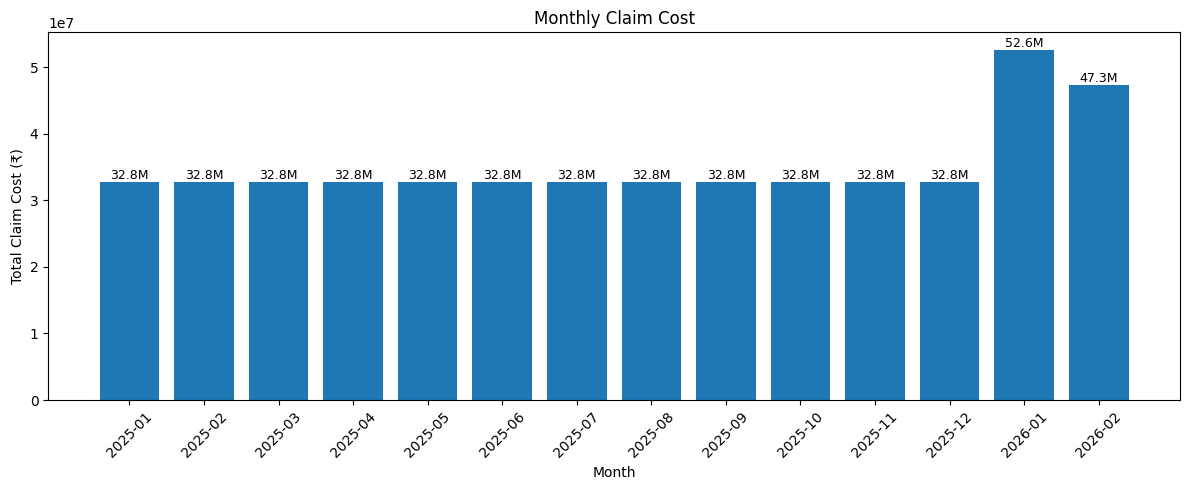

In [29]:
plot_data = claim_cost_by_month.copy()

plt.figure(figsize=(12, 5))
bars = plt.bar(plot_data["Claim_Year_Month"], plot_data["Total_Claim_Cost"])

plt.xticks(rotation=45)
plt.title("Monthly Claim Cost")
plt.xlabel("Month")
plt.ylabel("Total Claim Cost (₹)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

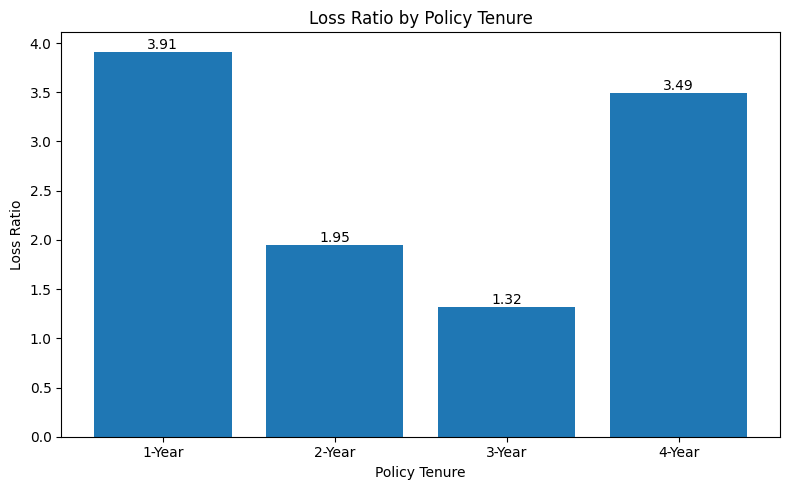

In [30]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    tenure_ratio["Policy_Tenure"].astype(str) + "-Year",
    tenure_ratio["Loss_Ratio"]
)

plt.title("Loss Ratio by Policy Tenure")
plt.xlabel("Policy Tenure")
plt.ylabel("Loss Ratio")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

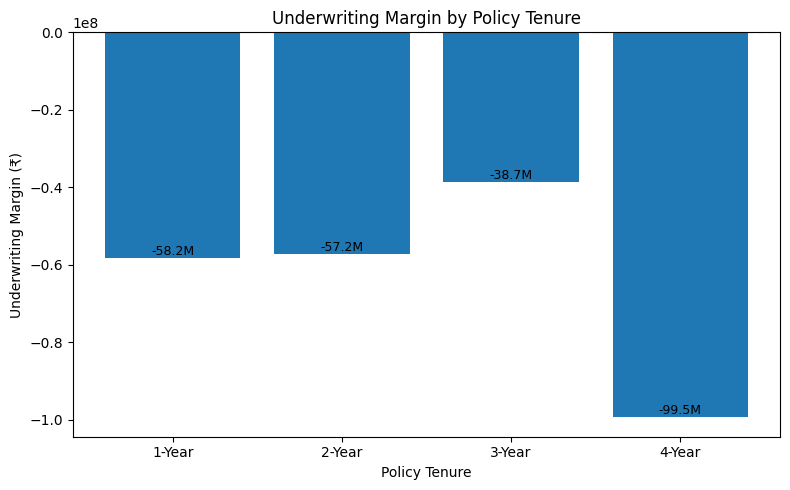

In [31]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    tenure_ratio["Policy_Tenure"].astype(str) + "-Year",
    tenure_ratio["Underwriting_Margin"]
)

plt.axhline(0, linestyle="--")
plt.title("Underwriting Margin by Policy Tenure")
plt.xlabel("Policy Tenure")
plt.ylabel("Underwriting Margin (₹)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

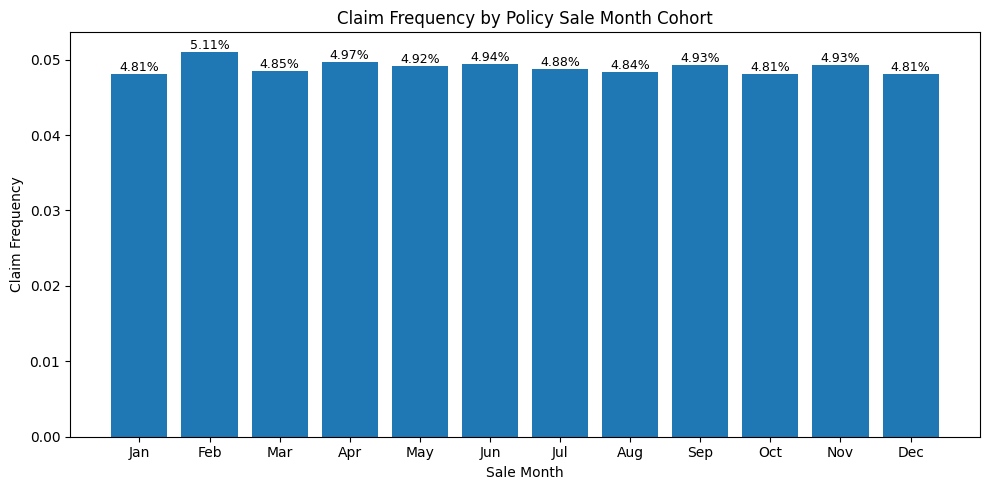

In [34]:
plt.figure(figsize=(10, 5))
bars = plt.bar(sale_month_cohort["Sale_Month"], sale_month_cohort["Claim_Frequency"])

plt.title("Claim Frequency by Policy Sale Month Cohort")
plt.xlabel("Sale Month")
plt.ylabel("Claim Frequency")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

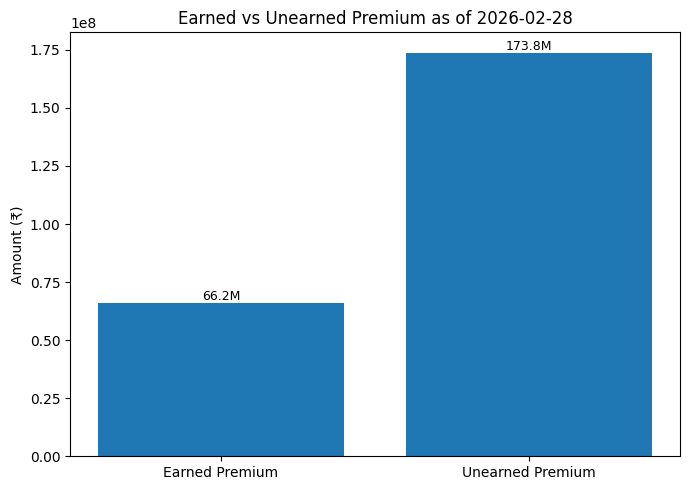

In [36]:
premium_split = pd.DataFrame({
    "Category": ["Earned Premium", "Unearned Premium"],
    "Amount": [premium_earned_till_feb_2026, unearned_premium_as_of_feb_2026]
})

plt.figure(figsize=(7, 5))
bars = plt.bar(premium_split["Category"], premium_split["Amount"])

plt.title("Earned vs Unearned Premium as of 2026-02-28")
plt.ylabel("Amount (₹)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 7. Key Insights and Conclusion

This section summarizes the key business findings from the simulation and analysis, including profitability, loss ratio, claim concentration, and future liability exposure.## 8. Key Insights

- The simulated portfolio is structurally unprofitable under the current premium assumptions, with a portfolio loss ratio of 1.64.
- Profitability pressure is broad-based across tenure bands; even the relatively best-performing segment remains underwriting negative.
- Sale-month cohort analysis shows that origination period affects later claim emergence, making cohort tracking useful for portfolio quality monitoring.
- A meaningful share of written premium remains unearned as of the analysis cutoff, while substantial active-policy exposure is still outstanding.
- The findings point to a pricing adequacy issue: the flat premium structure is insufficient relative to the simulated claim burden.

## 9. Conclusion
This project shows how a large-scale insurance portfolio can be simulated and analysed using Python across policy lifecycle logic, claims emergence, profitability, earned premium timing, and remaining exposure.

Although the assumptions are intentionally simplified, the framework is useful for evaluating underwriting sustainability and pricing adequacy in a controlled business scenario.



In [38]:
policy_sales.to_csv("policy_sales_data.csv", index=False)
claims_data.to_csv("claims_data.csv", index=False)

print("Files saved:")
print("- policy_sales_data.csv")
print("- claims_data.csv")

Files saved:
- policy_sales_data.csv
- claims_data.csv
